# Importing Data

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('passing_cleaned (1)_nfl_dataset_2001_2023.csv')

# Basic Statistics 

In [6]:
df.head(10)

,Unnamed: 0,Player,Tm,Age,G,GS,Cmp,Att,Cmp%,Yds,...,Y/C,Y/G,Rate,Sk,Yds-s,Sk%,NY/A,ANY/A,Year,Pro_Bowl_selected_unselected
0,0,Kurt Warner,STL,30,16,16,375,546,68.7,4830,...,12.9,301.9,101.4,38,233,6.5,7.87,7.41,2001,1
1,1,Peyton Manning,IND,25,16,16,343,547,62.7,4131,...,12.0,258.2,84.1,29,232,5.0,6.77,5.88,2001,0
2,2,Brett Favre,GNB,32,16,16,314,510,61.6,3921,...,12.5,245.1,94.1,22,151,4.1,7.09,7.02,2001,1
3,3,Aaron Brooks,NOR,25,16,16,312,558,55.9,3832,...,12.3,239.5,76.4,50,330,8.2,5.76,4.99,2001,0
4,4,Rich Gannon,OAK,36,16,16,361,549,65.8,3828,...,10.6,239.3,95.5,27,155,4.7,6.38,6.61,2001,1
5,5,Trent Green,KAN,31,16,16,296,523,56.6,3783,...,12.8,236.4,71.1,39,198,6.9,6.38,5.06,2001,0
6,6,Kerry Collins,NYG,29,16,16,327,568,57.6,3764,...,11.5,235.3,77.1,36,206,6.0,5.89,5.33,2001,0
7,7,Jake Plummer,ARI,27,16,16,304,525,57.9,3653,...,12.0,228.3,79.6,29,204,5.2,6.23,5.74,2001,0
8,8,Jeff Garcia,SFO,31,16,16,316,504,62.7,3538,...,11.2,221.1,94.8,26,114,4.9,6.46,6.65,2001,1
9,9,Doug Flutie,SDG,39,16,16,294,521,56.4,3464,...,11.8,216.5,72.0,25,168,4.6,6.04,5.10,2001,0


In [7]:
df.describe()

,Unnamed: 0,Age,G,GS,Cmp,Att,Cmp%,Yds,TD,TD%,...,Y/C,Y/G,Rate,Sk,Yds-s,Sk%,NY/A,ANY/A,Year,Pro_Bowl_selected_unselected
count,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2347.000000,...,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000,2351.000000
mean,1196.989792,28.139515,10.587410,6.896214,105.431306,170.556359,55.276648,1199.410889,7.305402,7.168215,...,10.669545,110.197320,77.356827,11.619311,75.758401,5.747154,6.448486,5.847371,2011.911102,0.082943
std,691.363673,4.369928,5.627281,6.388043,132.810264,209.403487,27.734747,1525.847789,10.255517,19.655481,...,8.246987,103.438748,32.112818,14.341790,94.525495,8.241281,7.549116,12.601788,6.794692,0.275855
min,0.000000,21.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-11.000000,0.000000,0.000000,...,-11.000000,-1.300000,0.000000,0.000000,0.000000,0.000000,-15.000000,-45.000000,2001.000000,0.000000
25%,598.500000,25.000000,5.000000,0.000000,1.000000,2.000000,50.000000,19.000000,0.000000,0.000000,...,8.300000,1.800000,56.200000,0.000000,0.000000,0.000000,3.780000,2.400000,2006.000000,0.000000
50%,1198.000000,27.000000,13.000000,5.000000,28.000000,49.000000,60.000000,296.000000,1.000000,2.900000,...,10.900000,93.400000,79.500000,4.000000,25.000000,5.000000,5.630000,5.090000,2012.000000,0.000000
75%,1794.500000,31.000000,16.000000,14.000000,204.000000,335.500000,66.700000,2311.500000,12.000000,4.800000,...,12.200000,205.650000,95.600000,22.000000,141.500000,7.700000,6.800000,6.830000,2018.000000,0.000000
max,2394.000000,45.000000,17.000000,17.000000,490.000000,733.000000,100.000000,5477.000000,55.000000,100.000000,...,81.000000,371.200000,158.300000,76.000000,477.000000,100.000000,81.000000,101.000000,2023.000000,1.000000


In [8]:
df.columns

Index(['Unnamed: 0', 'Player', 'Tm', 'Age', 'G', 'GS', 'Cmp', 'Att', 'Cmp%',
       'Yds', 'TD', 'TD%', 'Int', 'Int%', '1D', 'Lng', 'Y/A', 'AY/A', 'Y/C',
       'Y/G', 'Rate', 'Sk', 'Yds-s', 'Sk%', 'NY/A', 'ANY/A', 'Year',
       'Pro_Bowl_selected_unselected'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351 entries, 0 to 2350
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    2351 non-null   int64  
 1   Player                        2351 non-null   object 
 2   Tm                            2351 non-null   object 
 3   Age                           2351 non-null   int64  
 4   G                             2351 non-null   int64  
 5   GS                            2351 non-null   int64  
 6   Cmp                           2351 non-null   int64  
 7   Att                           2351 non-null   int64  
 8   Cmp%                          2351 non-null   float64
 9   Yds                           2351 non-null   int64  
 10  TD                            2351 non-null   int64  
 11  TD%                           2347 non-null   float64
 12  Int                           2351 non-null   int64  
 13  Int

In [10]:
df.dtypes  ## Improve dataset clarity-- everything is good here

Unnamed: 0                        int64
Player                           object
Tm                               object
Age                               int64
G                                 int64
GS                                int64
Cmp                               int64
Att                               int64
Cmp%                            float64
Yds                               int64
TD                                int64
TD%                             float64
Int                               int64
Int%                            float64
1D                                int64
Lng                               int64
Y/A                             float64
AY/A                            float64
Y/C                             float64
Y/G                             float64
Rate                            float64
Sk                                int64
Yds-s                             int64
Sk%                             float64
NY/A                            float64


In [11]:
df = df.drop(columns=['Unnamed: 0'])

## Checking Missing Value(s)

In [13]:
df.isnull().sum()  ## In the Excel datasheet, it seems there is one missing value. Granted, that is a small amount, but we want to eliminate any possibilities of data manipulation with erroneous data. 

Player                          0
Tm                              0
Age                             0
G                               0
GS                              0
Cmp                             0
Att                             0
Cmp%                            0
Yds                             0
TD                              0
TD%                             4
Int                             0
Int%                            1
1D                              0
Lng                             0
Y/A                             0
AY/A                            0
Y/C                             0
Y/G                             0
Rate                            0
Sk                              0
Yds-s                           0
Sk%                             0
NY/A                            0
ANY/A                           0
Year                            0
Pro_Bowl_selected_unselected    0
dtype: int64

## Handle Missing Values

In [15]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [16]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())  ## There was only one missing value. Rows with too many missing values may not provide enough useful information. If necessary, these rows can be removed to improve the quality of the final dataset. To handle missing values, the median was used for numerical columns since it provides a stable estimate that is not influenced by outliers.

df[numeric_cols].isnull().sum() ## Only numerical miussing value needed to be fixed here. 

Age                             0
G                               0
GS                              0
Cmp                             0
Att                             0
Cmp%                            0
Yds                             0
TD                              0
TD%                             0
Int                             0
Int%                            0
1D                              0
Lng                             0
Y/A                             0
AY/A                            0
Y/C                             0
Y/G                             0
Rate                            0
Sk                              0
Yds-s                           0
Sk%                             0
NY/A                            0
ANY/A                           0
Year                            0
Pro_Bowl_selected_unselected    0
dtype: int64

## Checking Duplicated Data

In [18]:
df.duplicated().sum() ## There are not any duplicated data, which is good. Duplicate rows can create unnecessary repetition and may affect the accuracy of later analysis. These rows are removed so that each observation in the dataset is unique.

0

# Separate Numeric and Categorical columns

In [49]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Pro_Bowl_selected_unselected')

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])  ## Outlier treatment was applied only to continuous numerical variables. The target variable was excluded since it represents a binary outcome and does not require outlier handling.    

# Dataset Outliers 

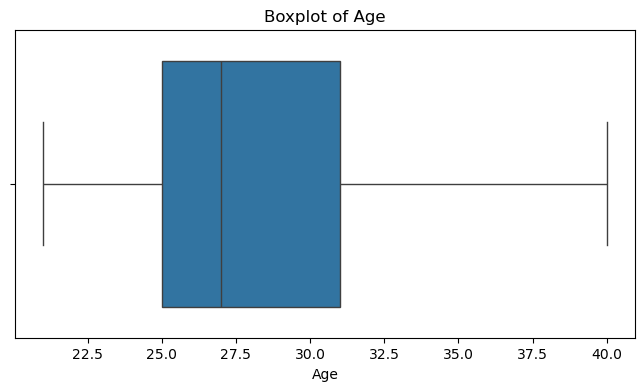

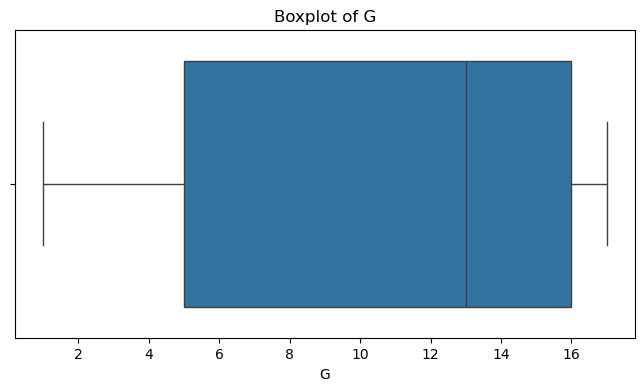

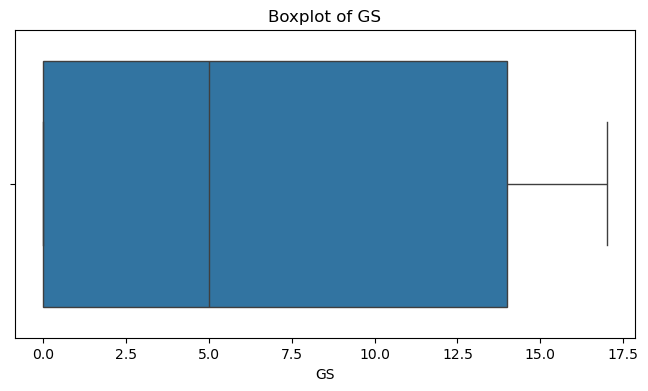

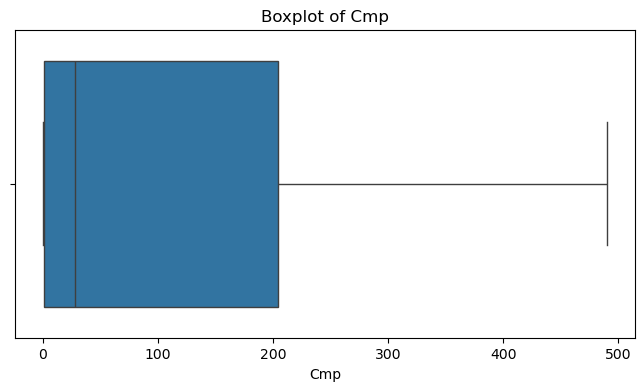

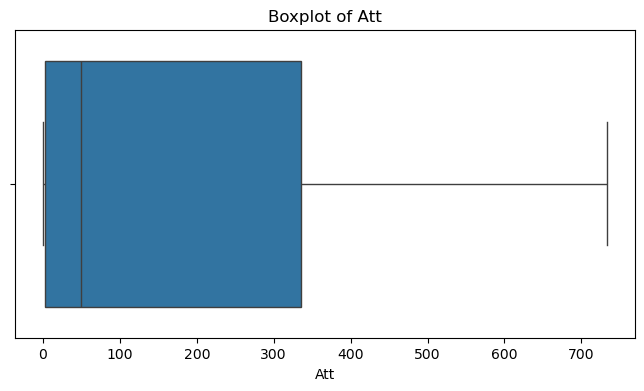

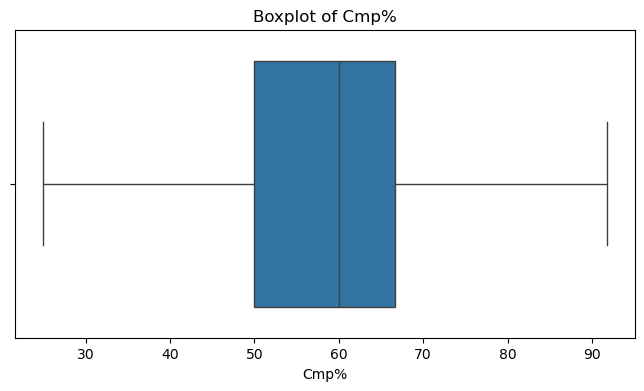

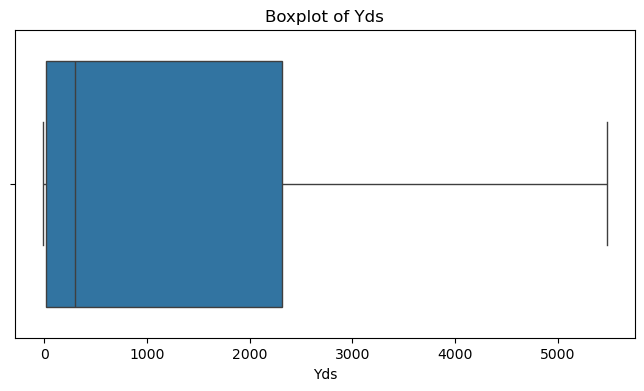

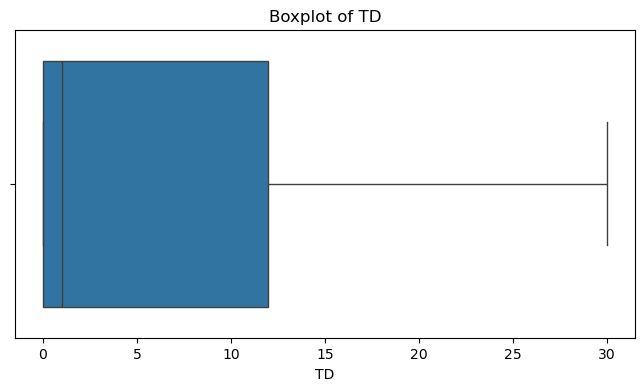

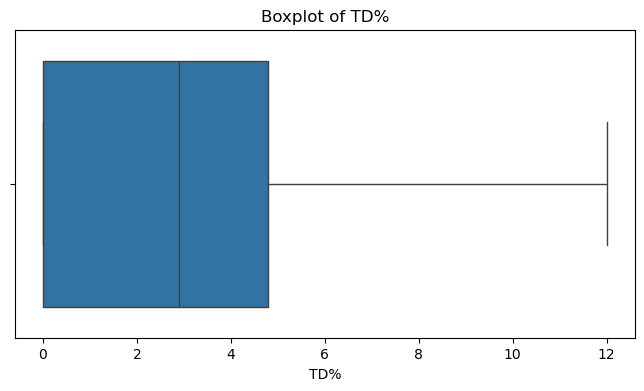

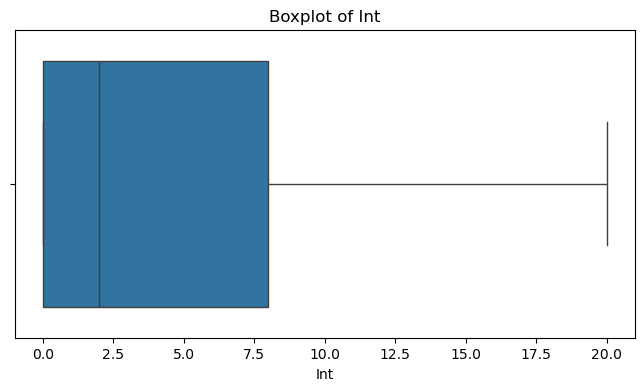

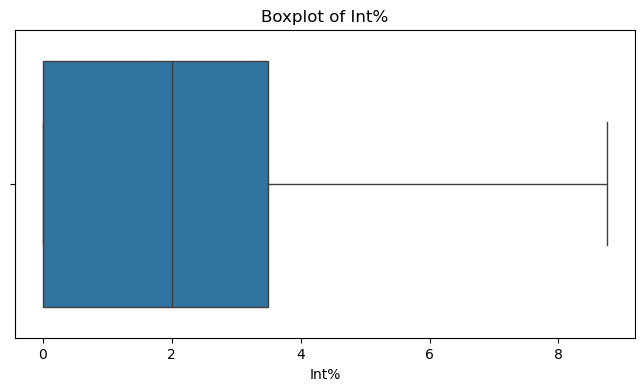

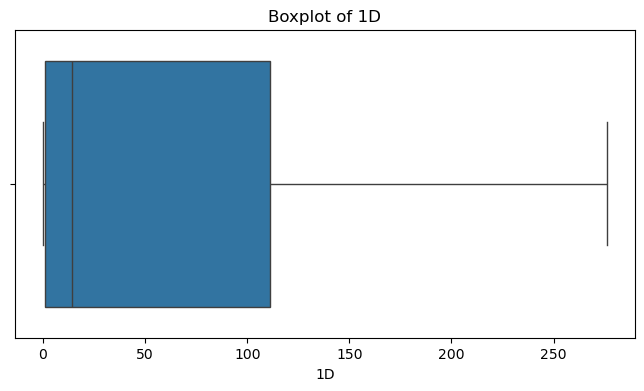

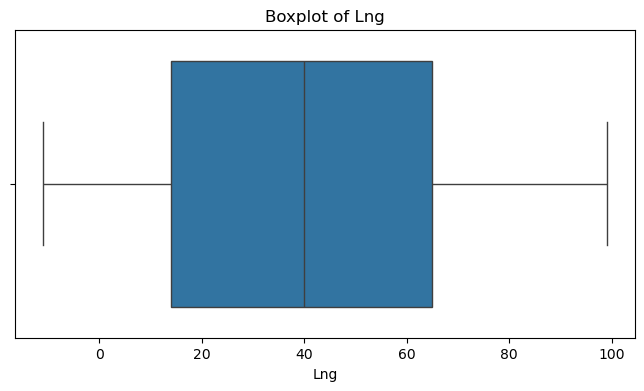

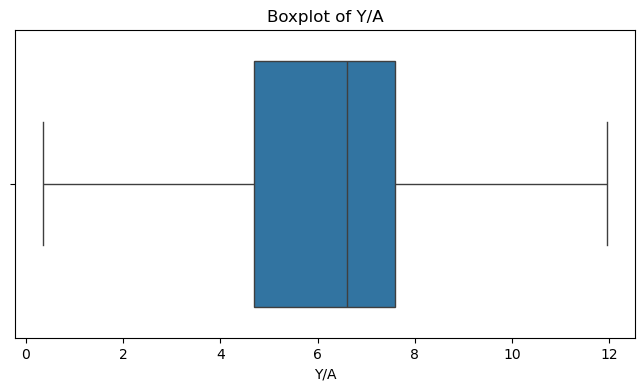

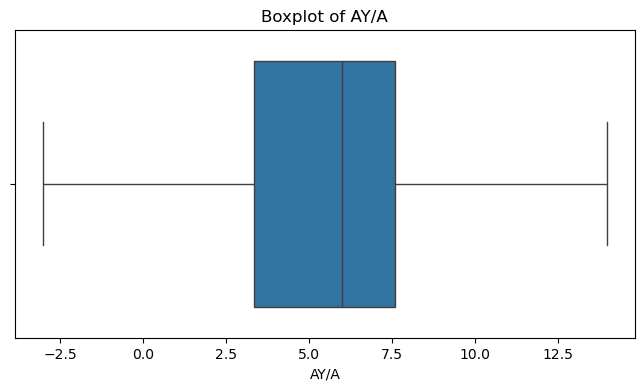

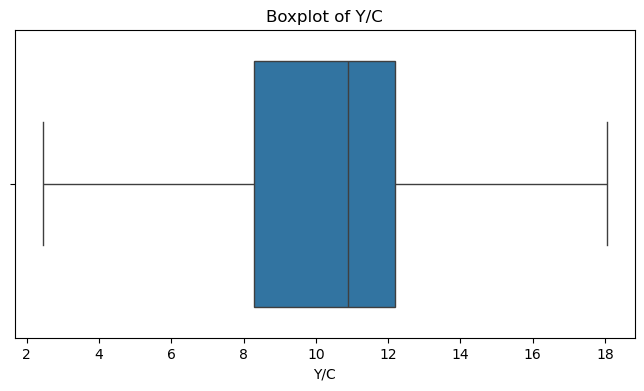

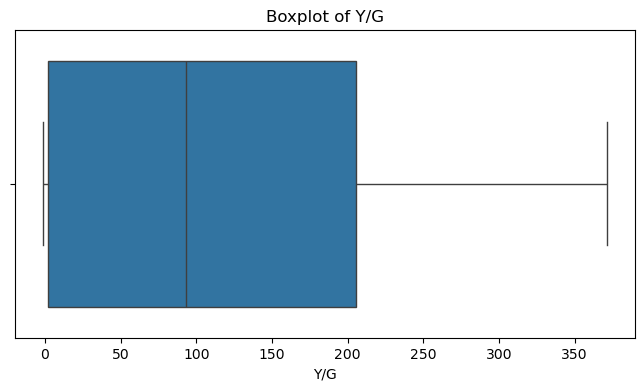

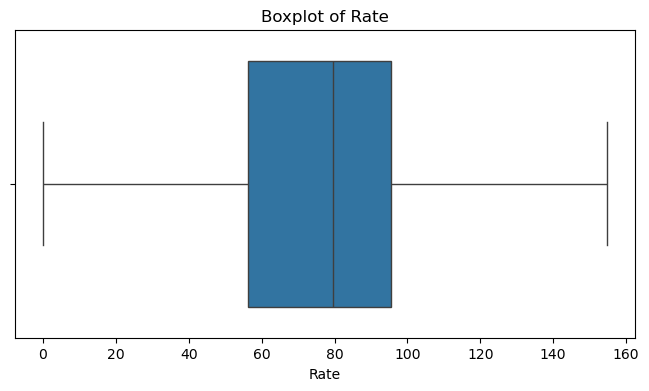

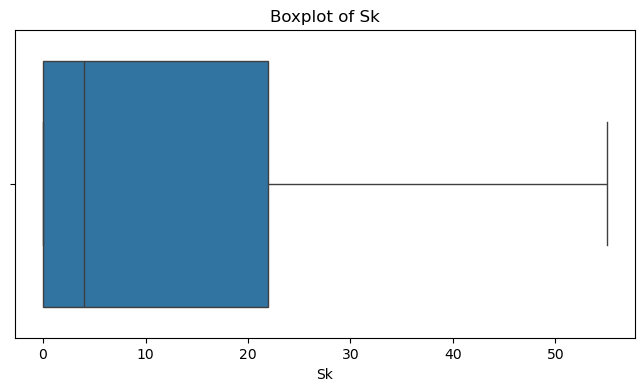

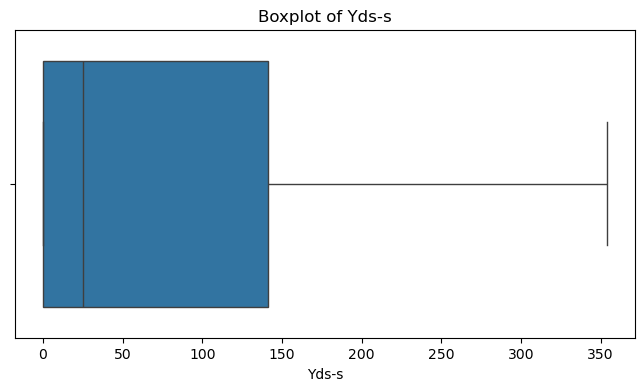

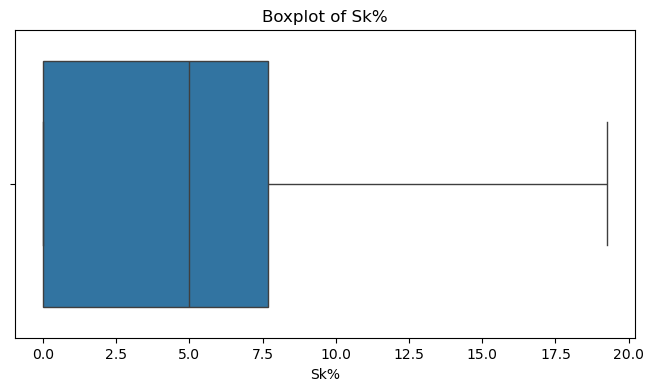

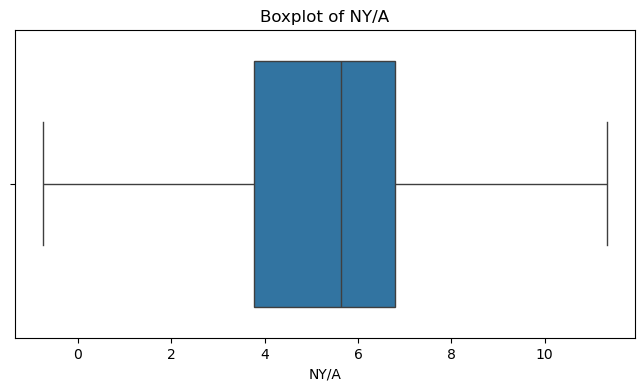

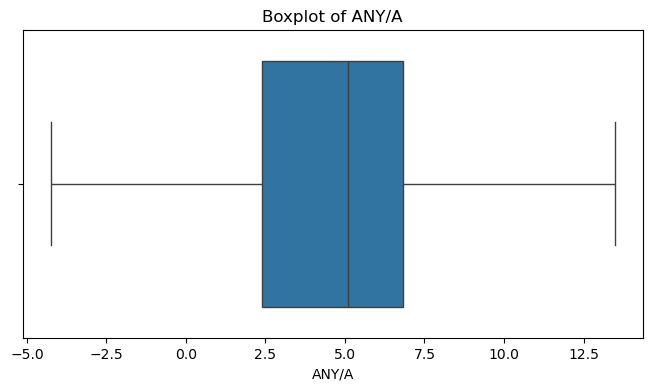

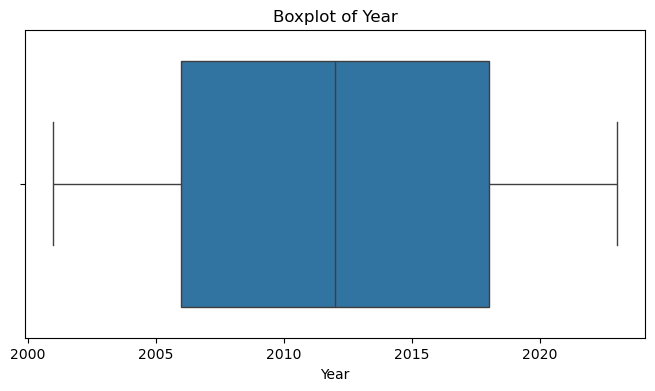

In [51]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show() # Detect Outliers

## Outliers are extreme values that may affect the accuracy of analysis. Boxplots were used to visually identify unusually high or low values across numerical columns.

## Adjusting Outliers

In [53]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

# Checking Dataset After Preprocessing

In [55]:
print("Dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())
df.head()

Dataset shape: (2351, 27)
Remaining missing values: 0
Remaining duplicate rows: 0


,Player,Tm,Age,G,GS,Cmp,Att,Cmp%,Yds,TD,...,Y/C,Y/G,Rate,Sk,Yds-s,Sk%,NY/A,ANY/A,Year,Pro_Bowl_selected_unselected
0,Kurt Warner,STL,30.0,16.0,16.0,375.0,546.0,68.7,4830.0,30.0,...,12.9,301.9,101.4,38.0,233.0,6.5,7.87,7.41,2001.0,1
1,Peyton Manning,IND,25.0,16.0,16.0,343.0,547.0,62.7,4131.0,26.0,...,12.0,258.2,84.1,29.0,232.0,5.0,6.77,5.88,2001.0,0
2,Brett Favre,GNB,32.0,16.0,16.0,314.0,510.0,61.6,3921.0,30.0,...,12.5,245.1,94.1,22.0,151.0,4.1,7.09,7.02,2001.0,1
3,Aaron Brooks,NOR,25.0,16.0,16.0,312.0,558.0,55.9,3832.0,26.0,...,12.3,239.5,76.4,50.0,330.0,8.2,5.76,4.99,2001.0,0
4,Rich Gannon,OAK,36.0,16.0,16.0,361.0,549.0,65.8,3828.0,27.0,...,10.6,239.3,95.5,27.0,155.0,4.7,6.38,6.61,2001.0,1


In [170]:
df = df[~df['Tm'].isin(['2TM', '3TM'])] ## Dropping Aggregrate Row 

# Univariate Analysis

## Numerical Variables

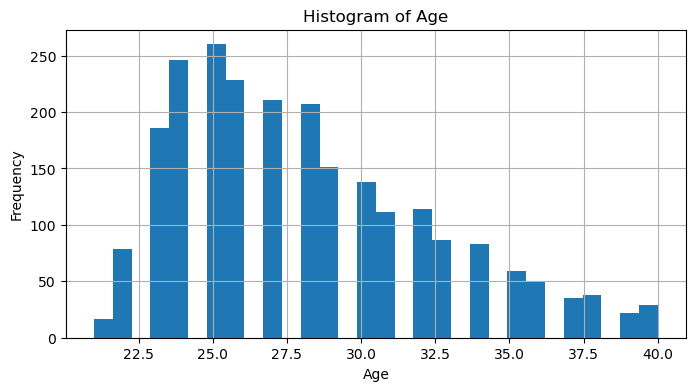

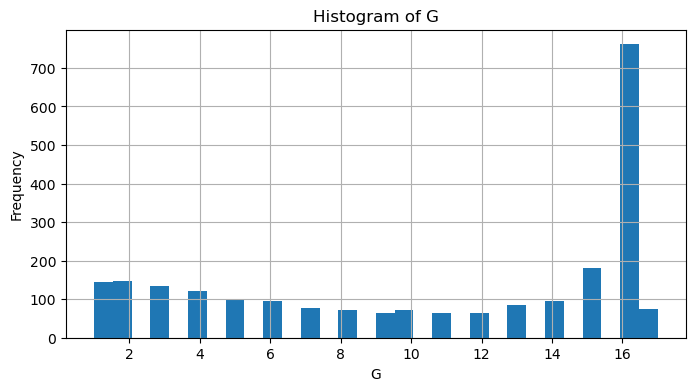

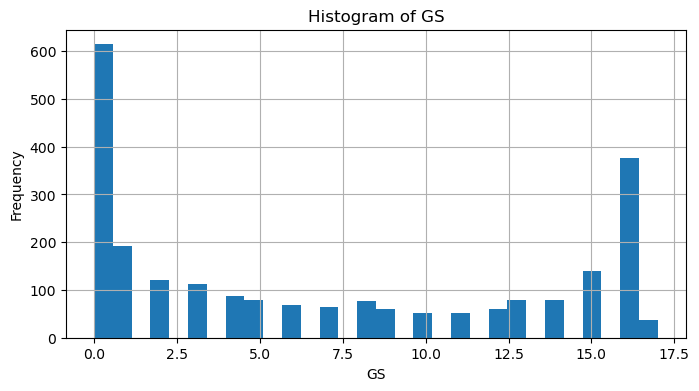

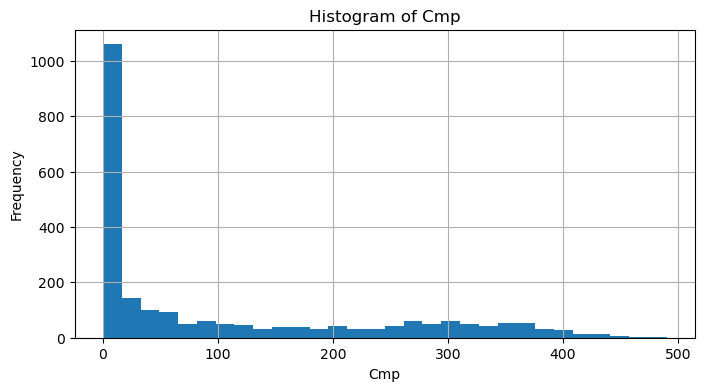

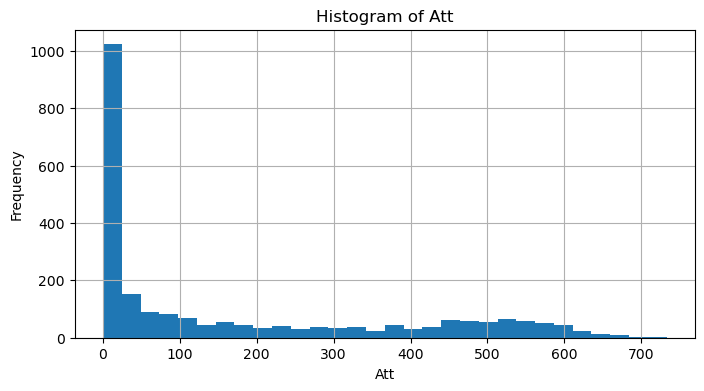

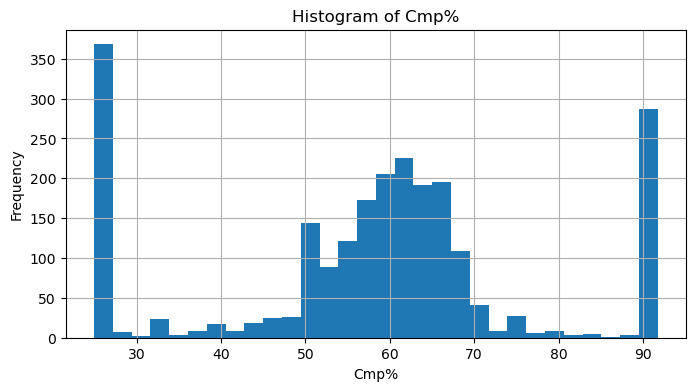

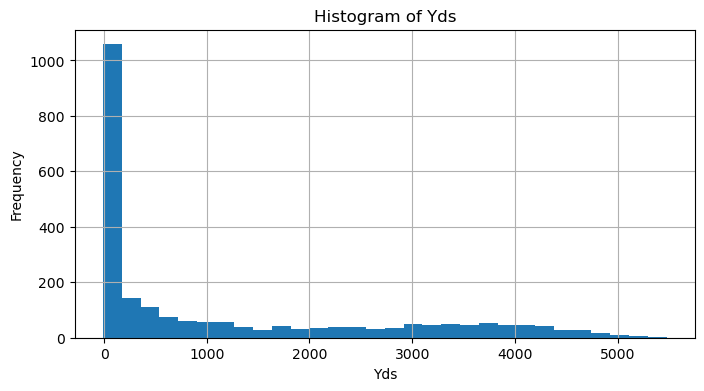

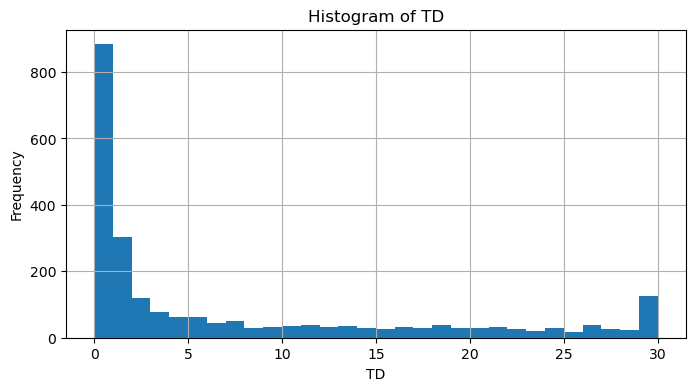

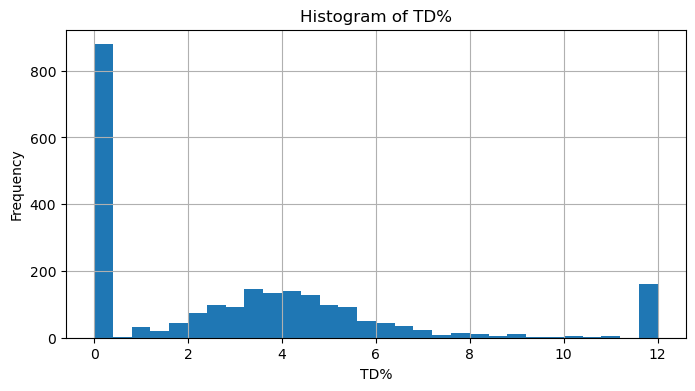

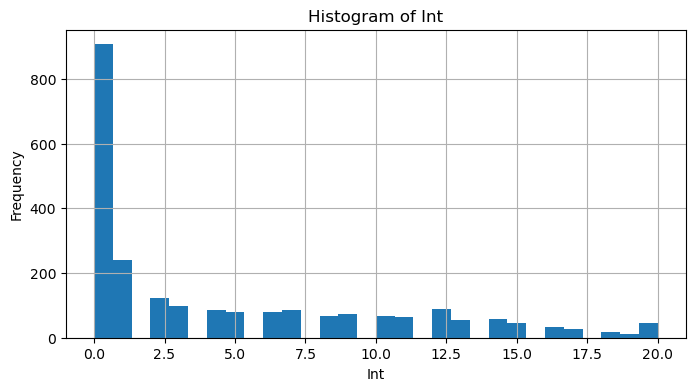

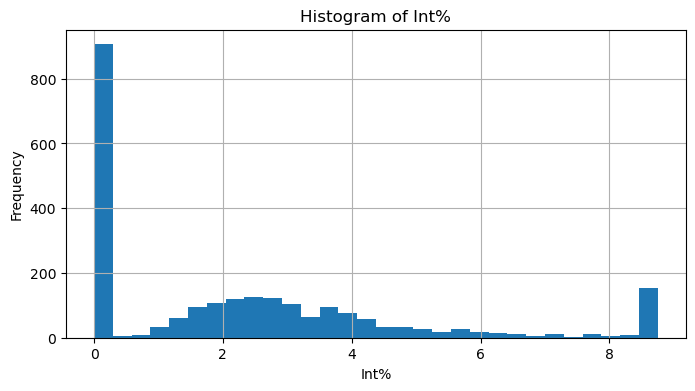

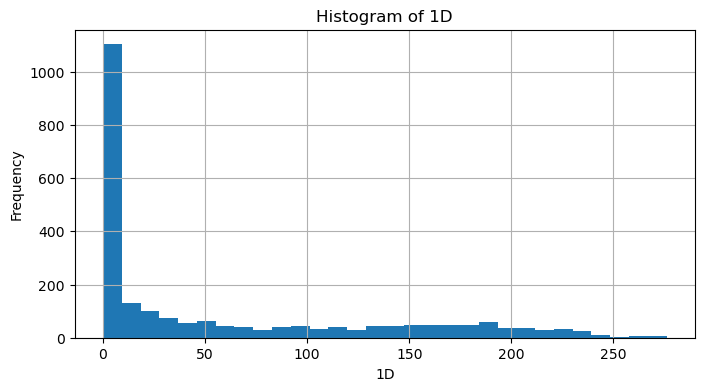

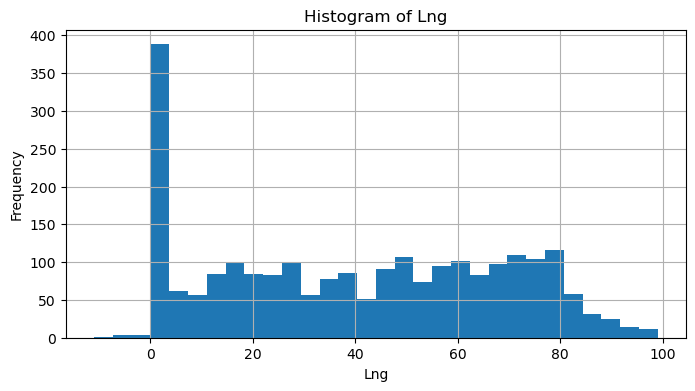

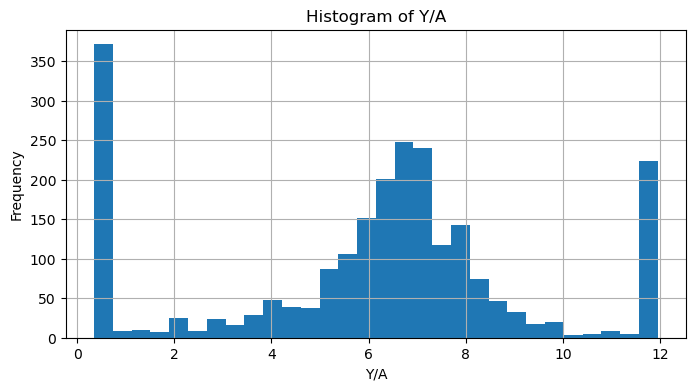

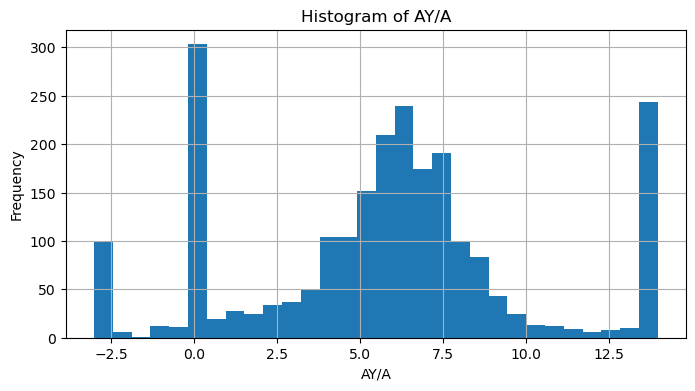

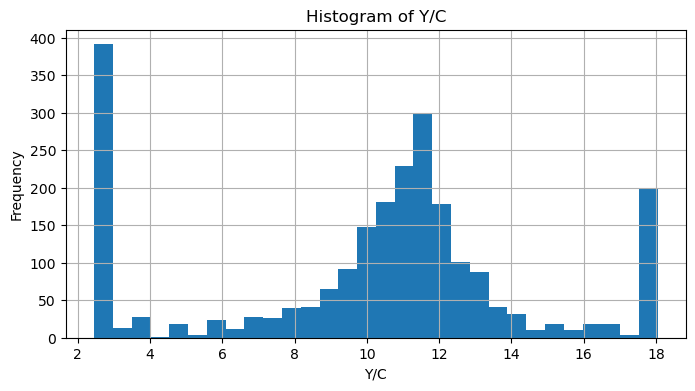

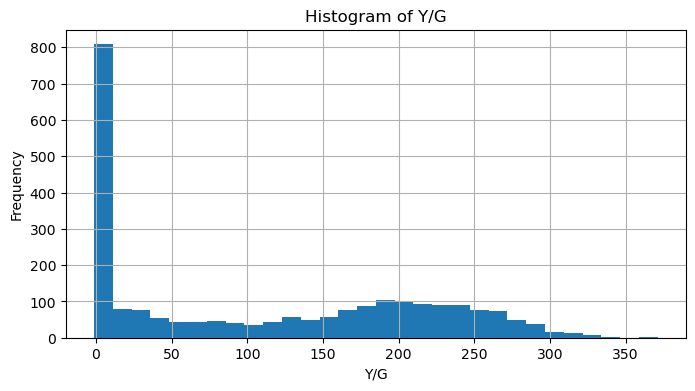

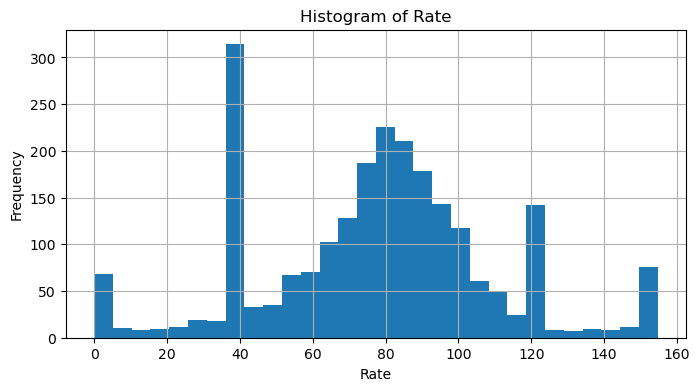

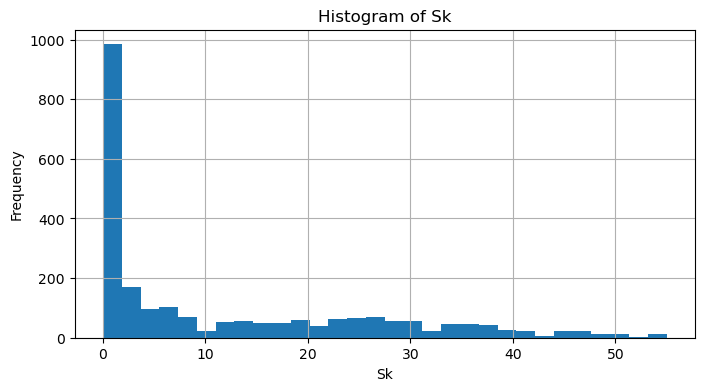

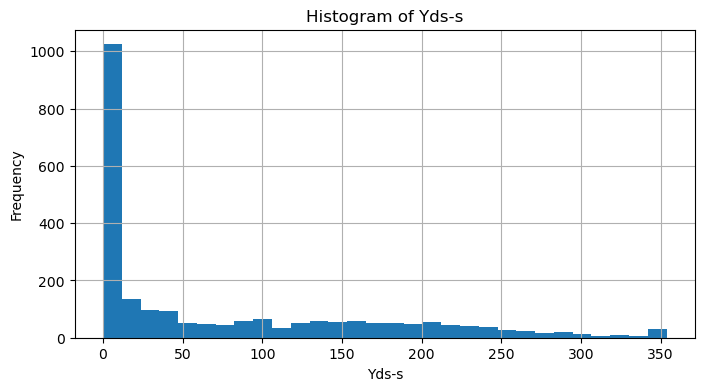

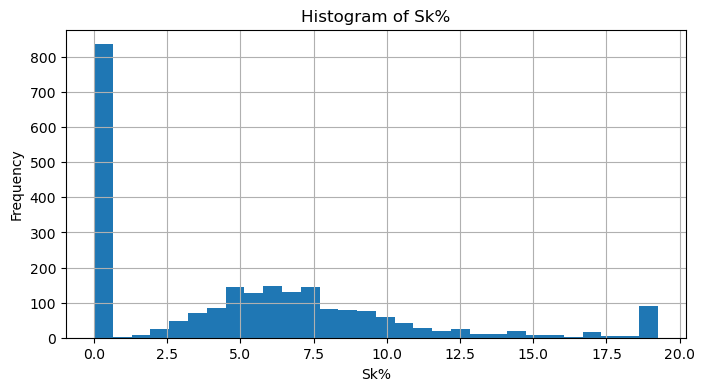

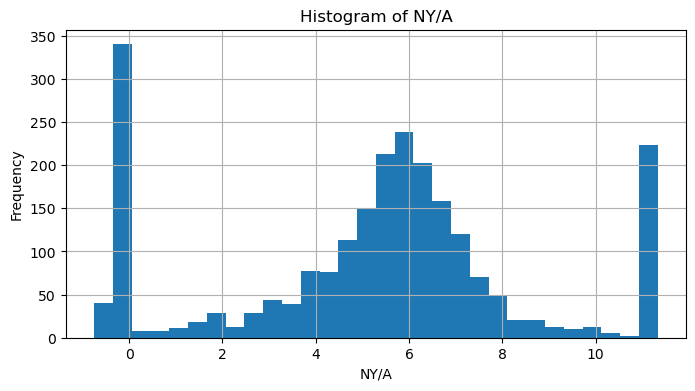

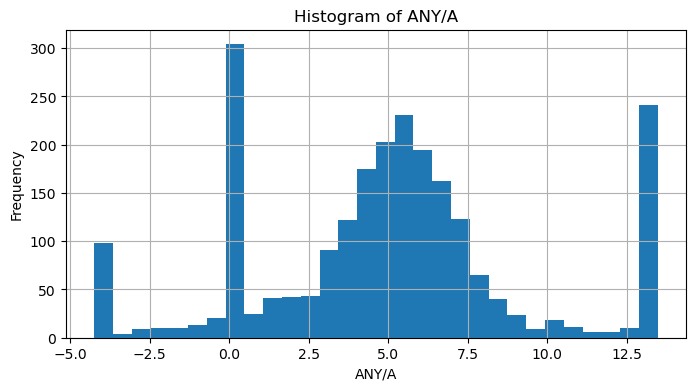

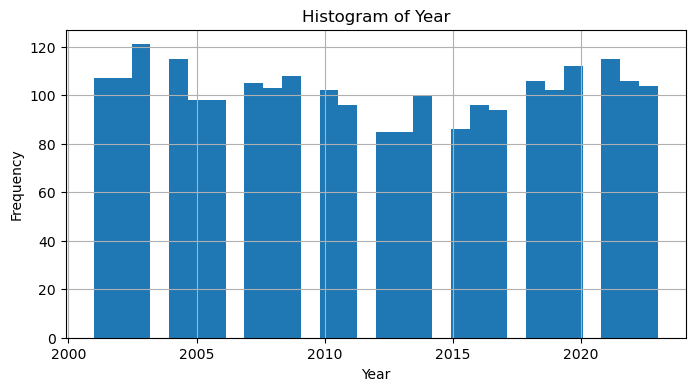

In [77]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    df[col].hist(bins=30)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show() 

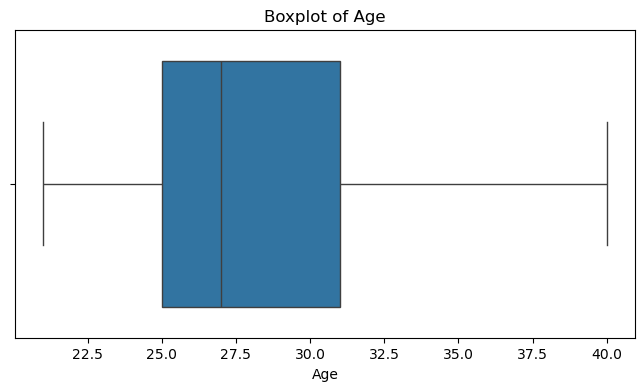

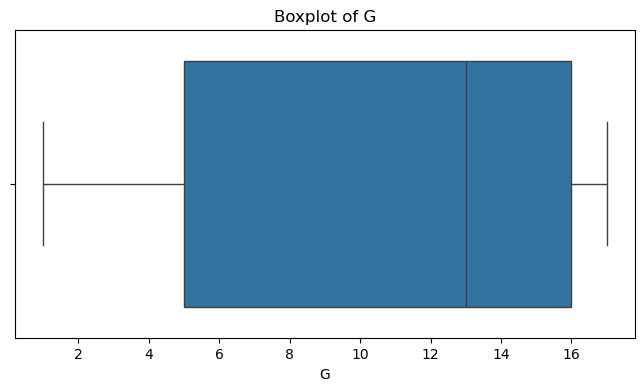

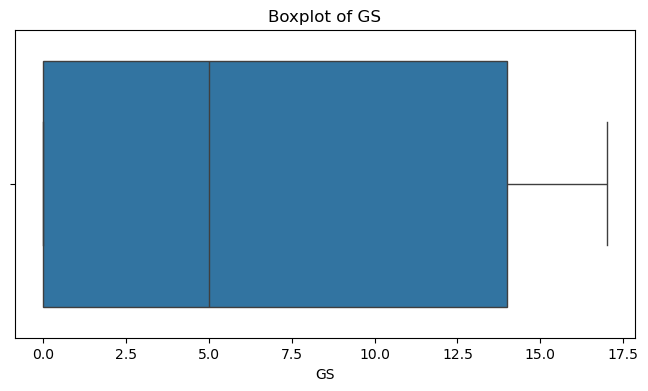

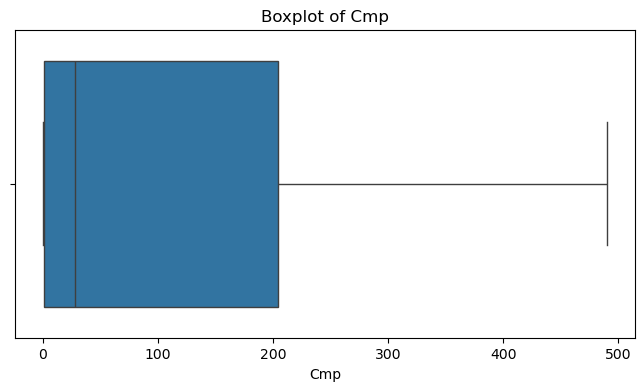

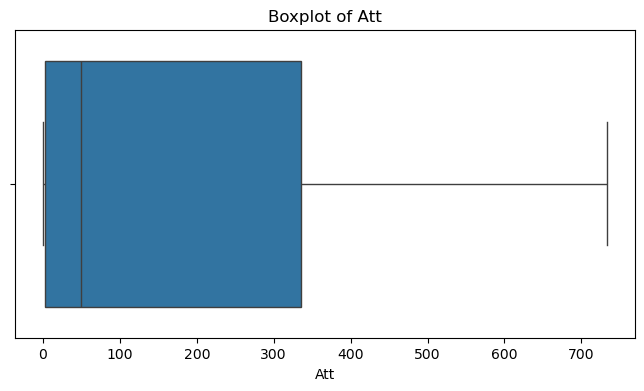

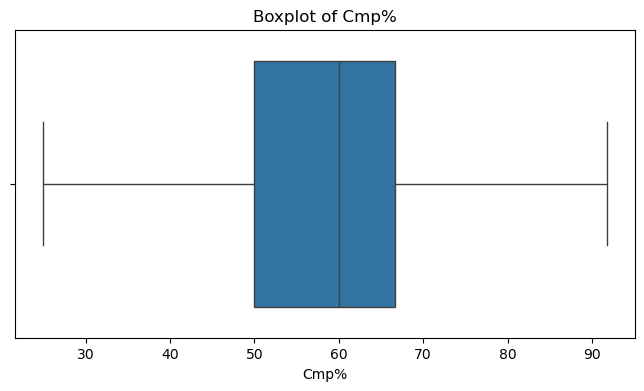

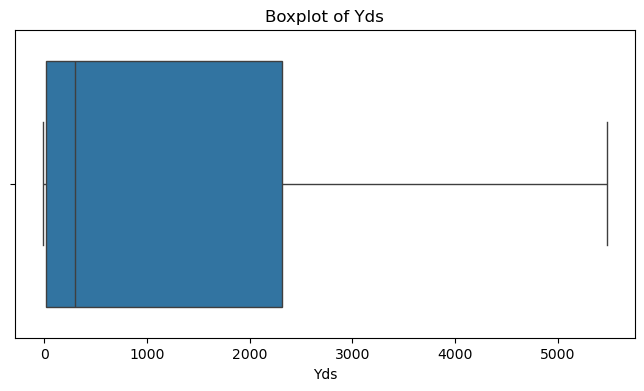

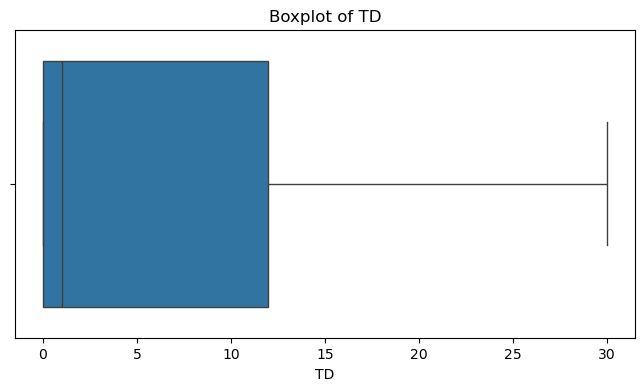

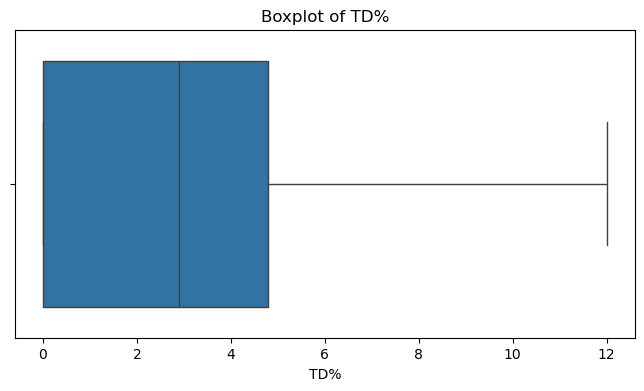

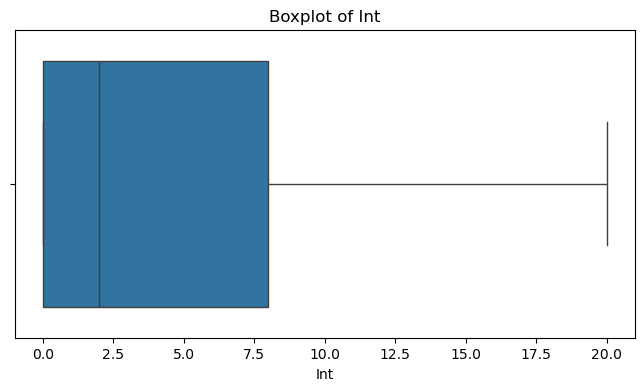

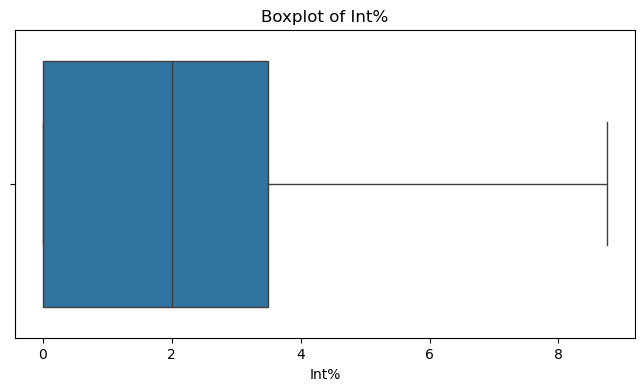

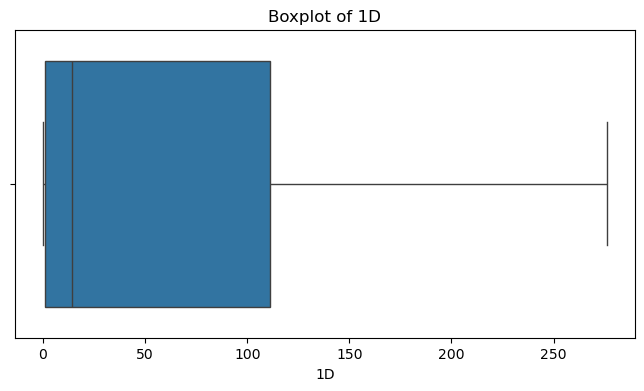

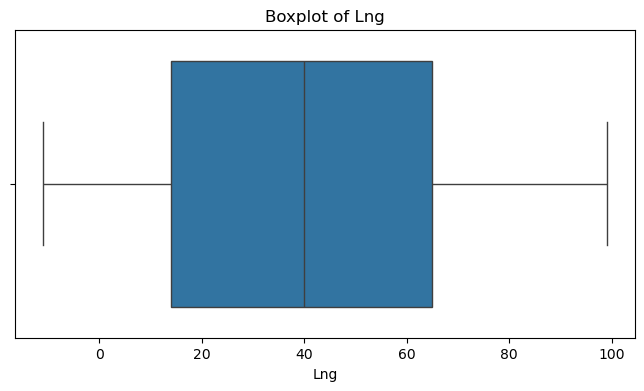

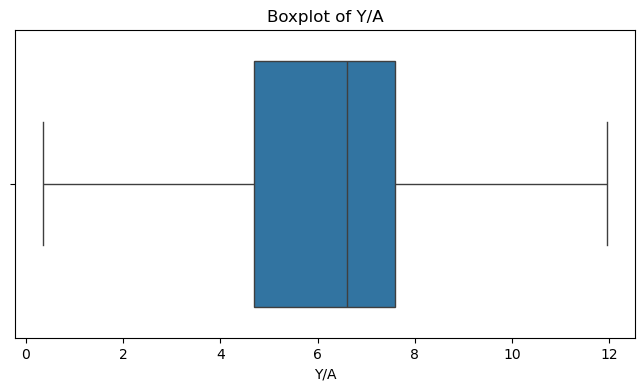

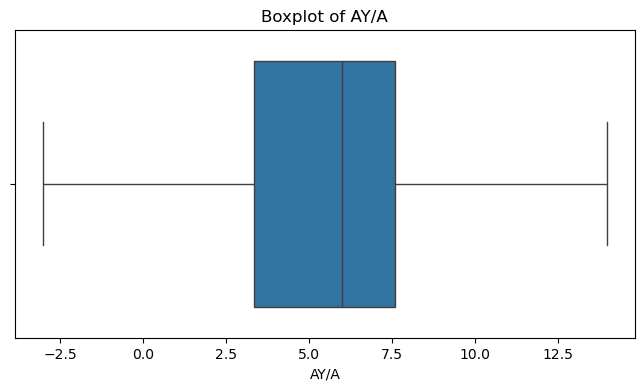

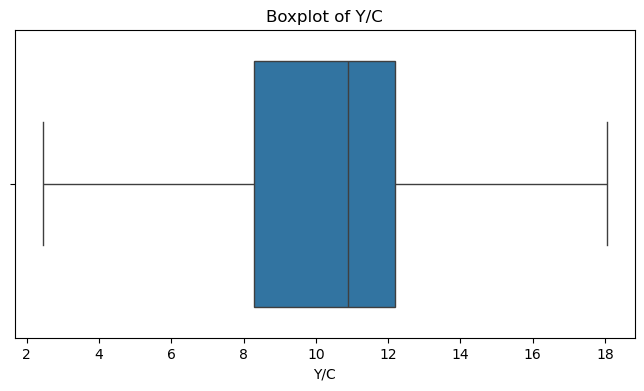

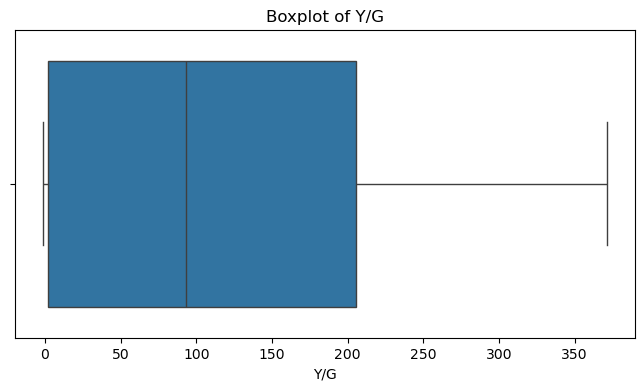

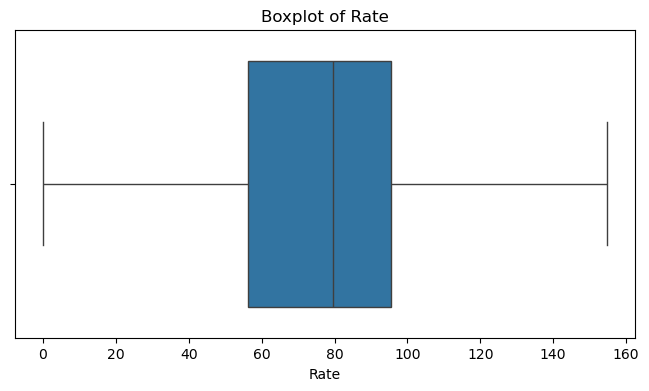

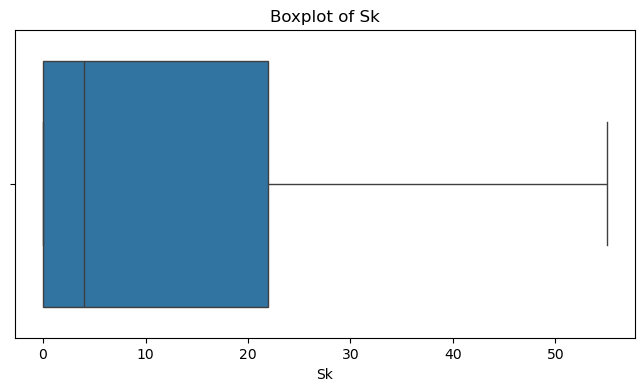

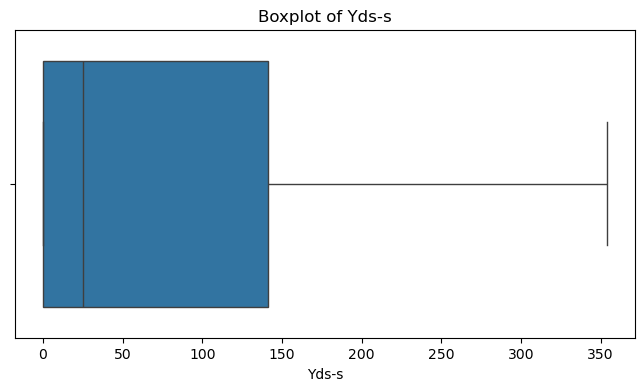

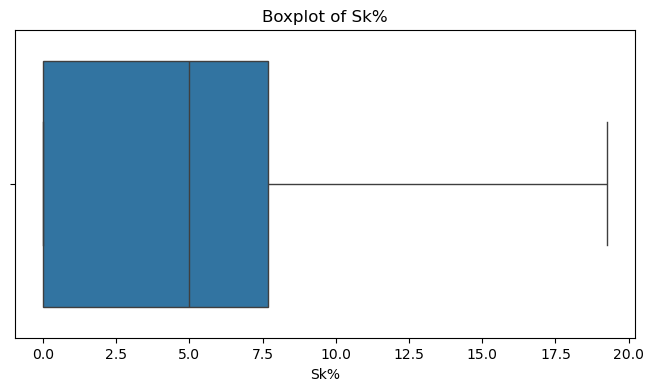

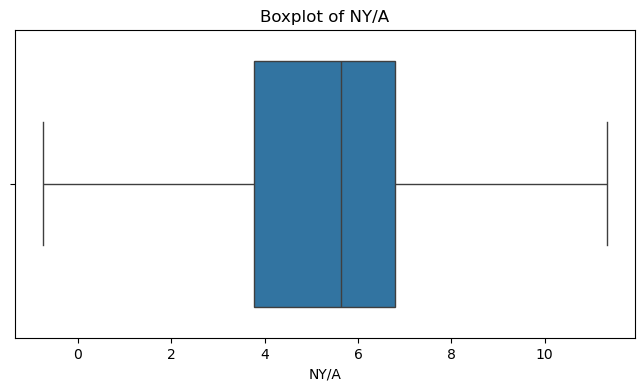

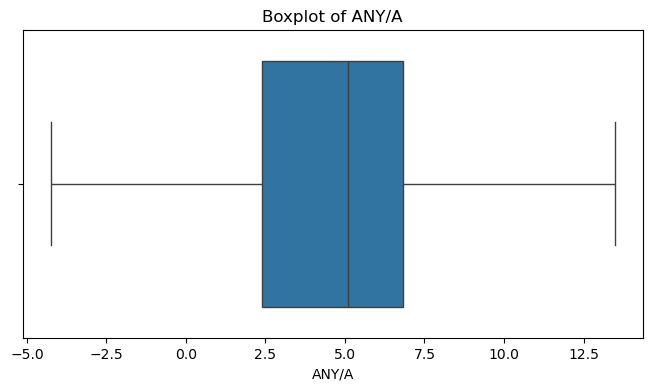

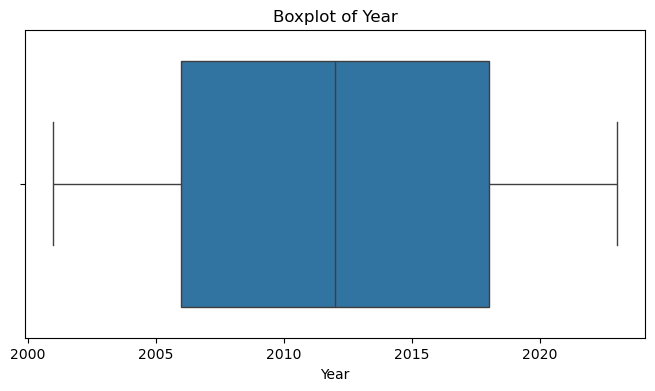

In [73]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()  

## This part, we did a univariate analysis performed on numerical variables using histograms and boxplots. Histograms were used to observe the distribution and spread of each variable, while boxplots were used to identify the presence of outliers and understand the overall range of the data.

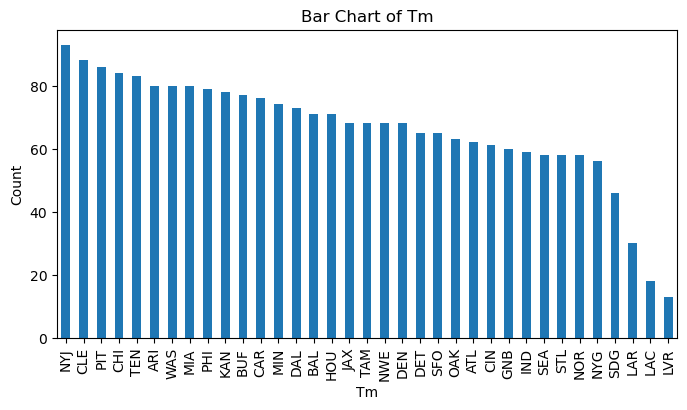

In [172]:
categorical_cols_filtered = [col for col in categorical_cols if col != 'Player']
for col in categorical_cols_filtered:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## The Player column was excluded from visualization due to its high number of unique values, which would make the bar chart difficult to interpret. Instead, the Tm (team) variable was used, as it provides a clearer and more meaningful distribution across categories.

# Bivariate and Multivariate Analysis

 ## Numerical vs. Numerical: Scatter plots, Correlation heatmaps.

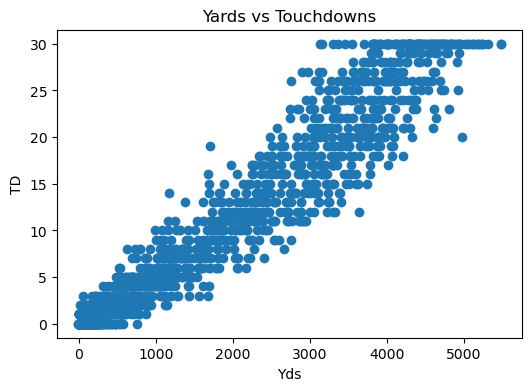

In [174]:
plt.figure(figsize=(6,4))
plt.scatter(df['Yds'], df['TD'])
plt.xlabel('Yds')
plt.ylabel('TD')
plt.title('Yards vs Touchdowns')
plt.show()

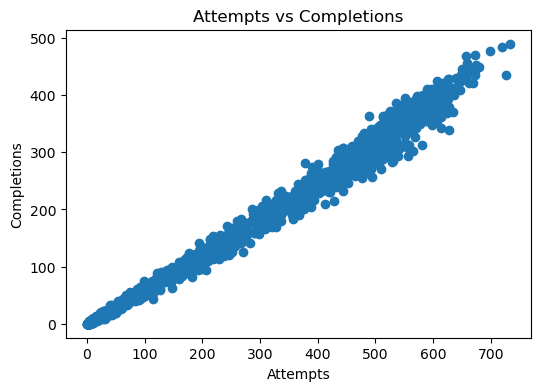

In [176]:
plt.figure(figsize=(6,4))
plt.scatter(df['Att'], df['Cmp'])
plt.xlabel('Attempts')
plt.ylabel('Completions')
plt.title('Attempts vs Completions')
plt.show()

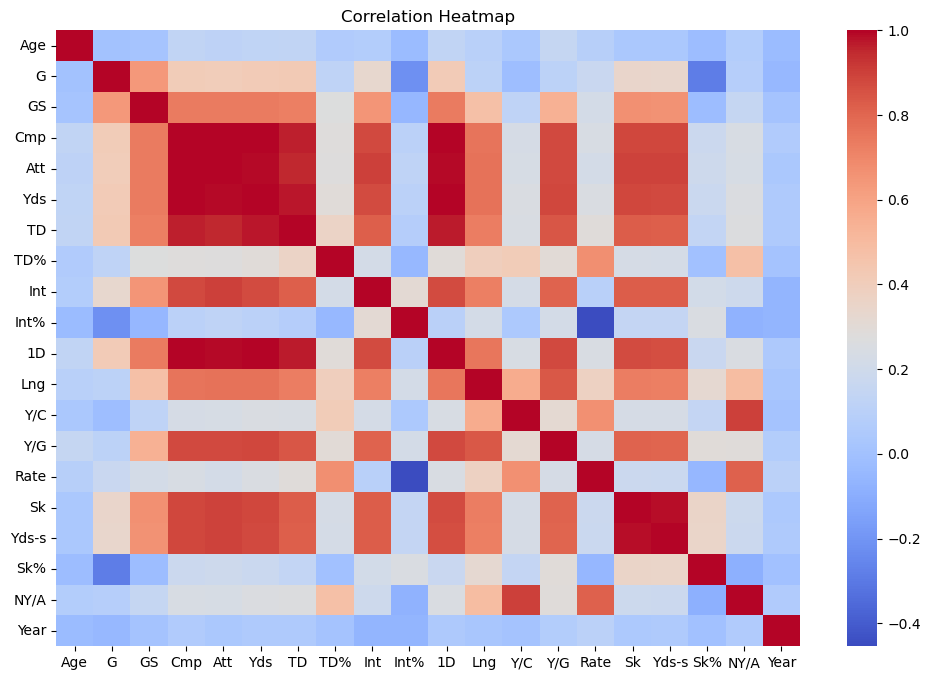

In [178]:
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## In the numerical analysis here, the heatmap shows strong positive relationships between passing volume stats such as attempts, completions, yards, and touchdowns. Efficiency metrics like Y/A, AY/A, and ANY/A are also closely related. Interceptions and interception percentage show weaker or negative relationships with performance measures.

In [180]:
df = df.drop(columns=['AY/A', 'ANY/A'])

KeyError: "['AY/A', 'ANY/A'] not found in axis"

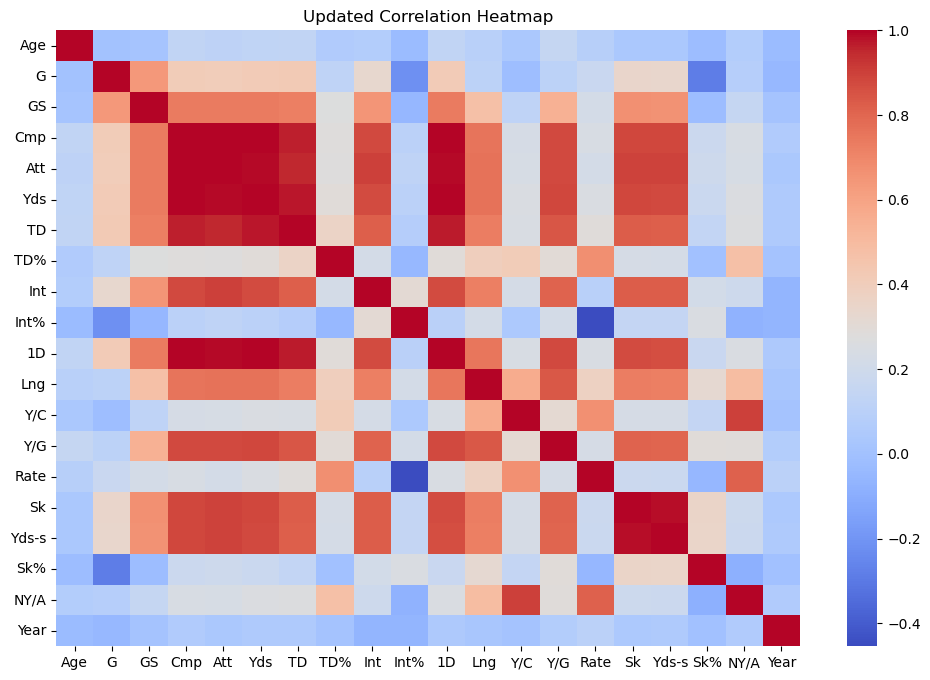

In [182]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Pro_Bowl_selected_unselected')

plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title('Updated Correlation Heatmap')
plt.show()
 ## The scatter plots show some variation in spread across values, suggesting mild multicollinearity in the data. Therefore, I removed a few features. 
## I updated the correlation heatmap and remove redundant features to eliminate duplicate information in the dataset. The target variable was excluded to focus on relationships between numerical features. The updated heatmap provides a clearer view of the correlations without unnecessary duplication.

# Numerical vs. Categorical 

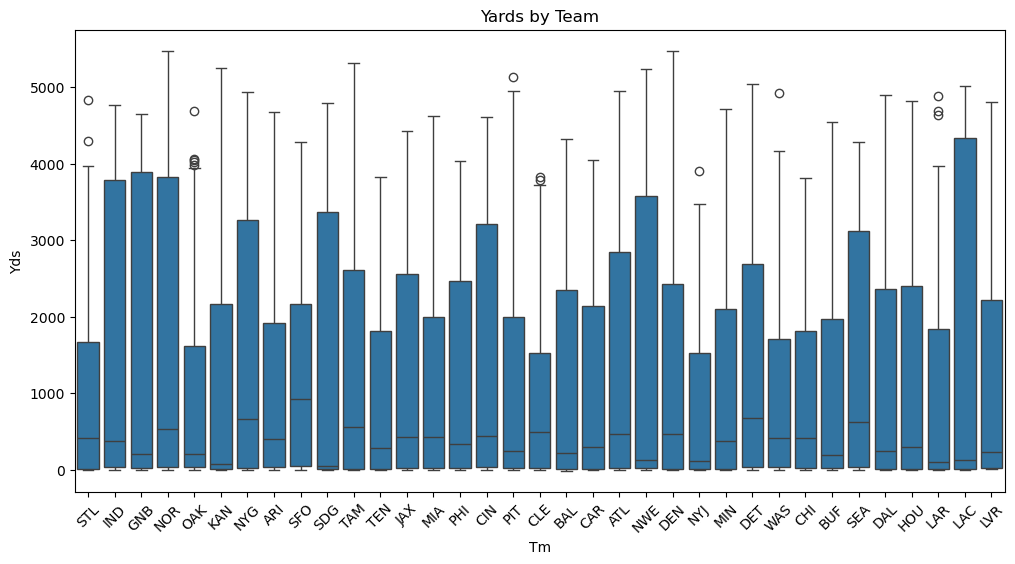

In [184]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Tm', y='Yds', data=df)
plt.title('Yards by Team')
plt.xticks(rotation=45)
plt.show()

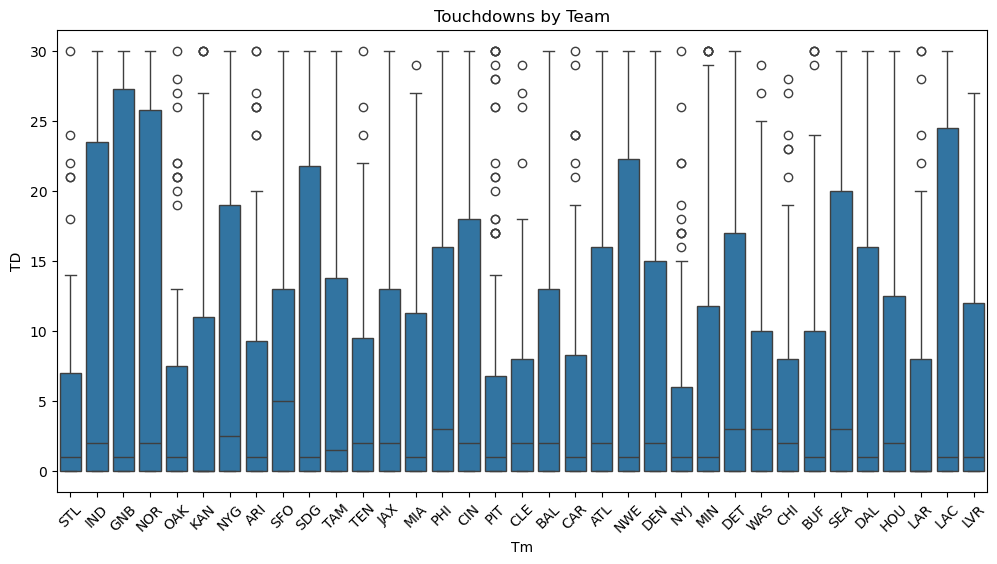

In [186]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Tm', y='TD', data=df)
plt.title('Touchdowns by Team')
plt.xticks(rotation=45)
plt.show()

## Here, it shows the boxplots and grouped bar charts to examine the relationship between numerical and categorical variables. The visualizations display how performance metrics such as yards and touchdowns vary across different teams, highlighting differences in distribution and average performance.

## Categorical vs Categorical

In [194]:
ct = pd.crosstab(df['Tm'], df['Pro_Bowl_selected_unselected'])
print(ct)

Pro_Bowl_selected_unselected   0   1
Tm                                  
ARI                           76   4
ATL                           55   7
BAL                           67   4
BUF                           73   4
CAR                           72   4
CHI                           83   1
CIN                           55   6
CLE                           87   1
DAL                           66   7
DEN                           63   5
DET                           63   2
GNB                           46  14
HOU                           65   6
IND                           46  13
JAX                           66   2
KAN                           66  12
LAC                           15   3
LAR                           27   3
LVR                           12   1
MIA                           79   1
MIN                           68   6
NOR                           46  12
NWE                           54  14
NYG                           53   3
NYJ                           92   1
O

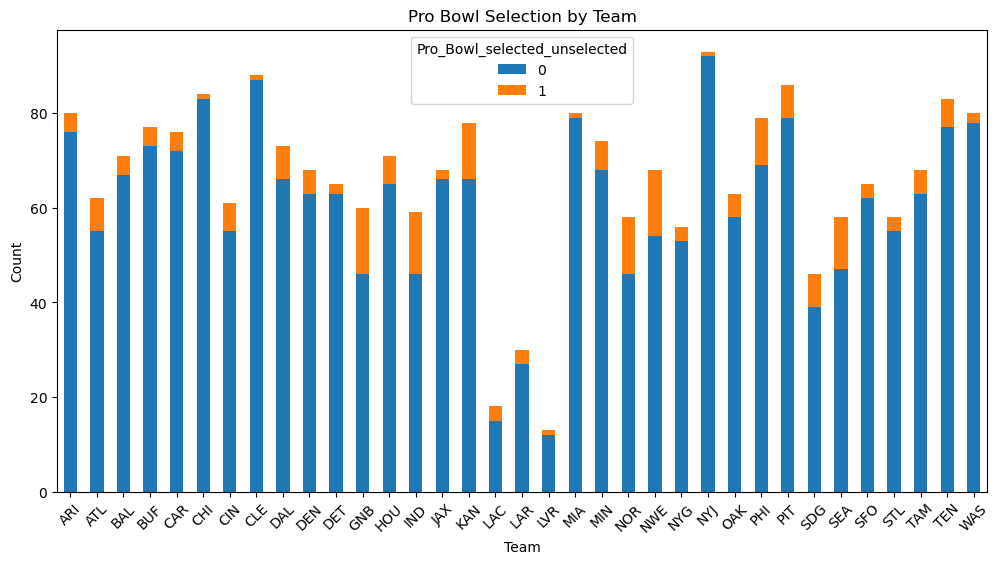

In [196]:
ct.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Pro Bowl Selection by Team')
plt.xlabel('Team')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Crosstabs and stacked bar charts were used to examine the relationship between categorical variables. This analysis shows how Pro Bowl selections are distributed across teams, allowing for comparison of category frequencies.

 ## Additonally, Passing volume stats such as attempts, completions, and yards are strongly related to each other. Touchdowns generally increase with higher passing yards and attempts. Efficiency metrics are closely aligned, indicating consistent performance measures. Pro Bowl selections tend to be more common among players with higher production and efficiency.

In [205]:
corr = df[numeric_cols].corr()
print(corr)

            Age         G        GS       Cmp       Att       Yds        TD  \
Age    1.000000  0.002387  0.015922  0.132704  0.118616  0.129180  0.132703   
G      0.002387  1.000000  0.637625  0.412031  0.408110  0.416406  0.420855   
GS     0.015922  0.637625  1.000000  0.734525  0.735967  0.736394  0.721729   
Cmp    0.132704  0.412031  0.734525  1.000000  0.996027  0.994635  0.961969   
Att    0.118616  0.408110  0.735967  0.996027  1.000000  0.991358  0.953562   
Yds    0.129180  0.416406  0.736394  0.994635  0.991358  1.000000  0.972070   
TD     0.132703  0.420855  0.721729  0.961969  0.953562  0.972070  1.000000   
TD%    0.061188  0.121326  0.271016  0.281392  0.272954  0.295302  0.362616   
Int    0.073645  0.331498  0.647910  0.878711  0.899983  0.874708  0.821062   
Int%  -0.031965 -0.220479 -0.054650  0.105739  0.122250  0.102598  0.074051   
1D     0.132259  0.417269  0.734530  0.994559  0.990431  0.997327  0.971433   
Lng    0.096252  0.109272  0.474688  0.756304  0.766

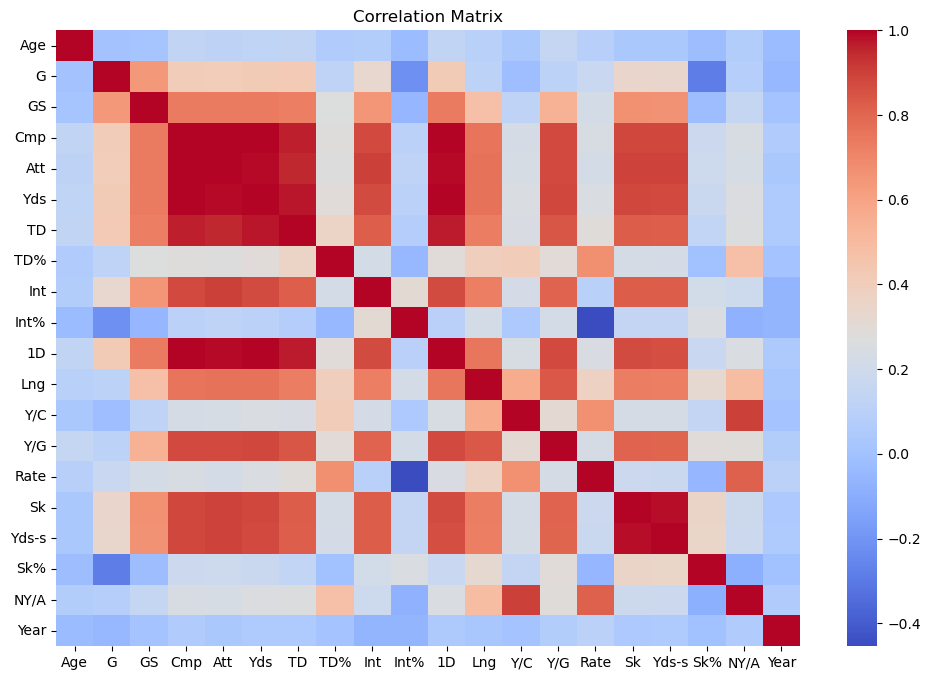

In [207]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [213]:
high_corr = corr.abs().unstack()
high_corr = high_corr[high_corr > 0.8]
high_corr = high_corr[high_corr < 1] 
print(high_corr.sort_values(ascending=False))

Yds    1D       0.997327
1D     Yds      0.997327
Att    Cmp      0.996027
Cmp    Att      0.996027
       Yds      0.994635
                  ...   
Int    Y/G      0.808556
Sk     Y/G      0.807525
Y/G    Sk       0.807525
       Yds-s    0.804756
Yds-s  Y/G      0.804756
Length: 78, dtype: float64


In [219]:
print("Total missing values:", df.isnull().sum().sum())

df.isnull().sum() 

## Double Checking Missing Values-- and as expected, there are not any missing values. That is a good sign, esepcially after some analysis. 

Total missing values: 0


Player                          0
Tm                              0
Age                             0
G                               0
GS                              0
Cmp                             0
Att                             0
Yds                             0
TD                              0
TD%                             0
Int                             0
Int%                            0
1D                              0
Lng                             0
Y/C                             0
Y/G                             0
Rate                            0
Sk                              0
Yds-s                           0
Sk%                             0
NY/A                            0
Year                            0
Pro_Bowl_selected_unselected    0
dtype: int64

In [223]:
unique_vals = df.nunique()

print(unique_vals)  ## A review of unique values for each column was also performed to ensure that variables are correctly classified as numerical or categorical.

Player                           715
Tm                                35
Age                               20
G                                 17
GS                                18
Cmp                              409
Att                              560
Yds                             1254
TD                                31
TD%                               92
Int                               21
Int%                              84
1D                               256
Lng                              107
Y/C                              125
Y/G                             1189
Rate                             696
Sk                                55
Yds-s                            317
Sk%                              212
NY/A                             551
Year                              23
Pro_Bowl_selected_unselected       2
dtype: int64


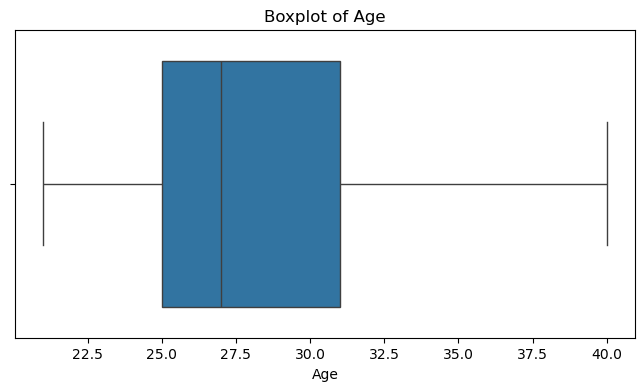

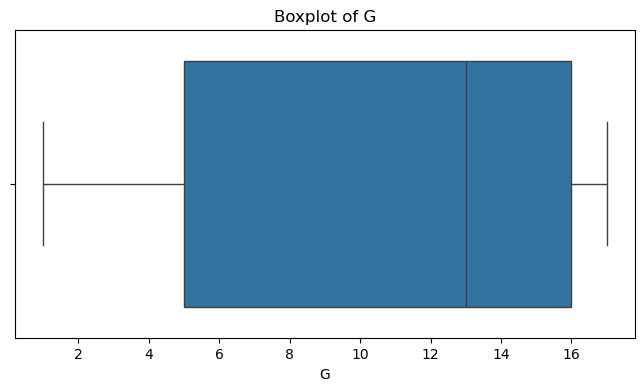

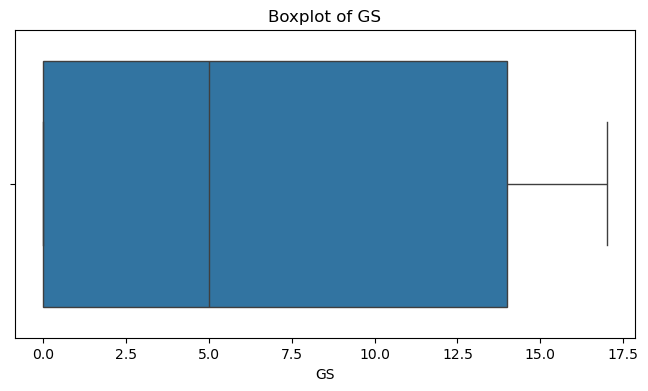

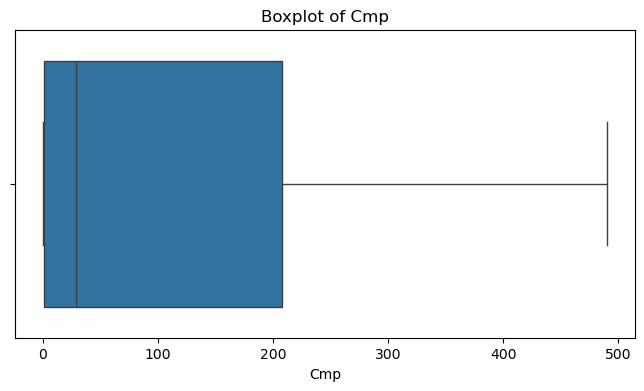

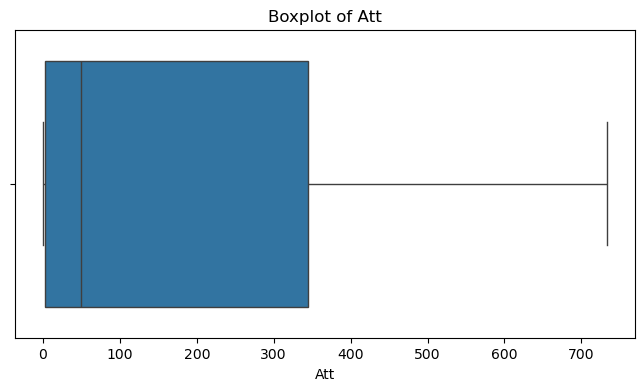

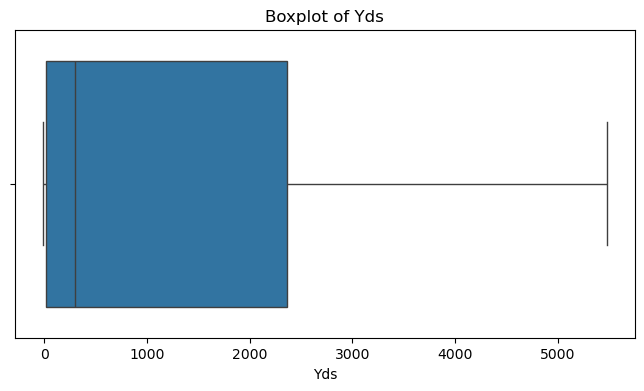

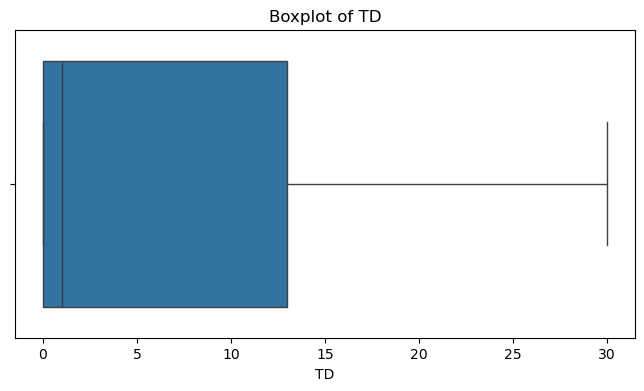

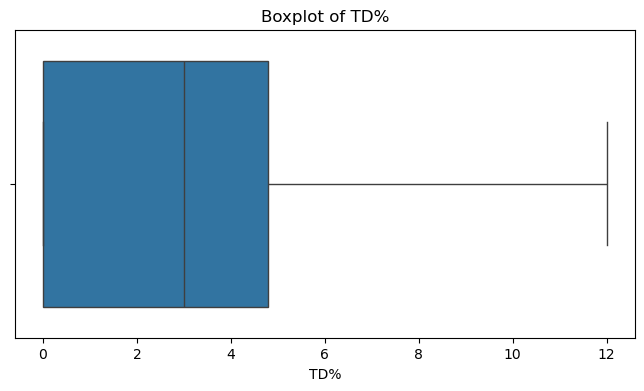

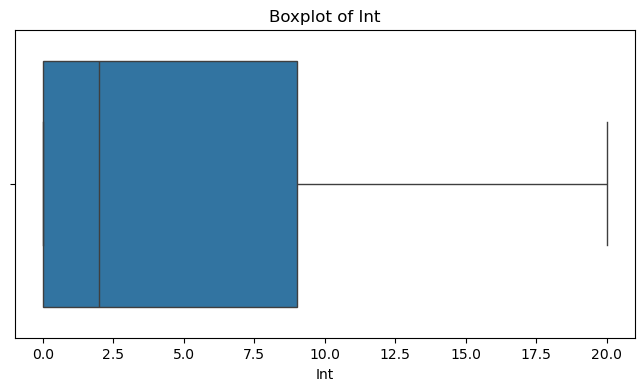

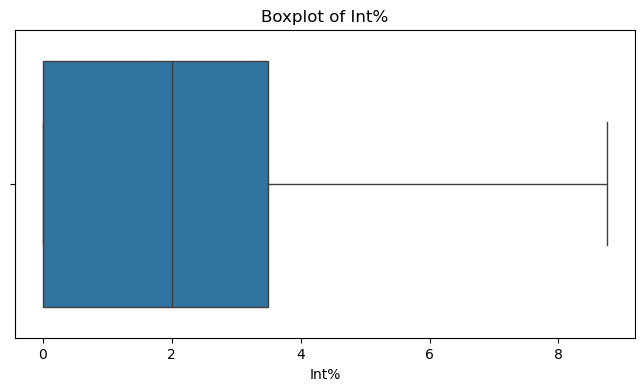

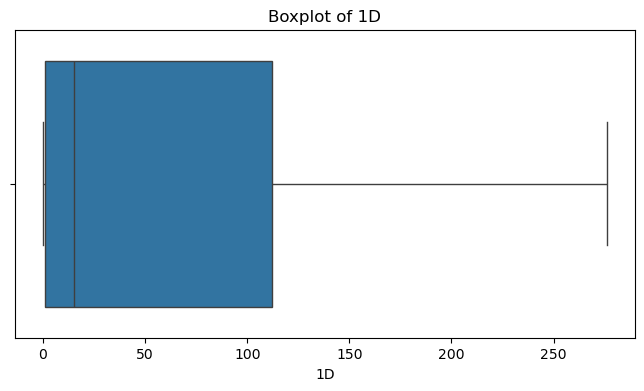

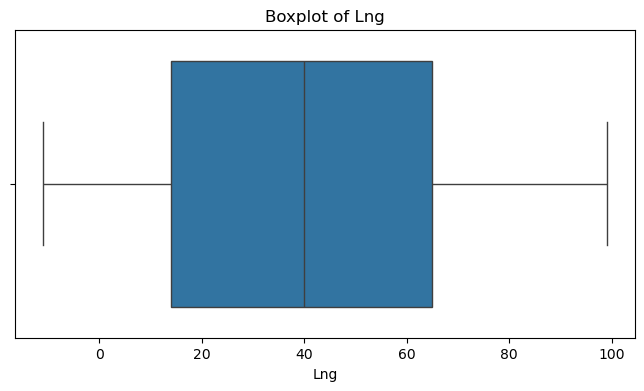

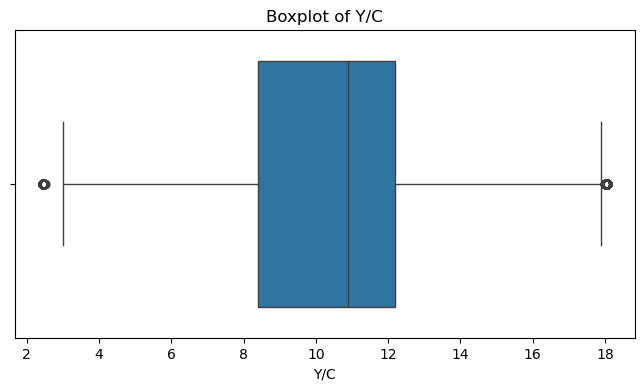

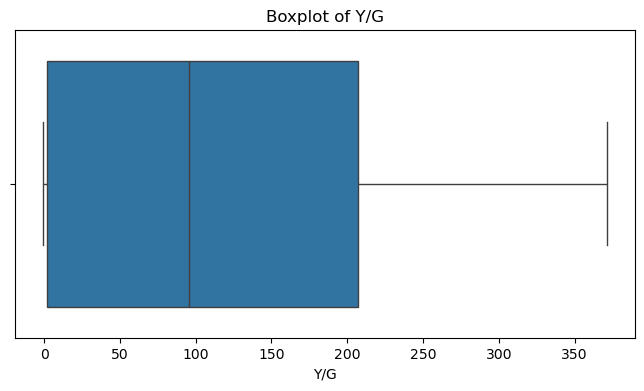

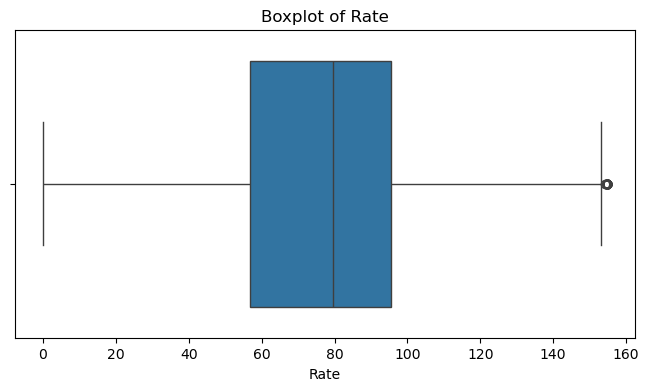

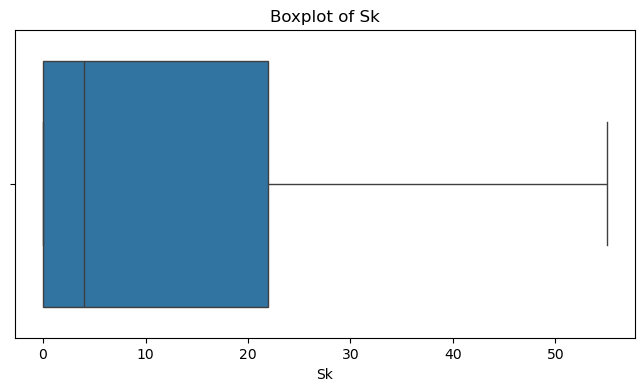

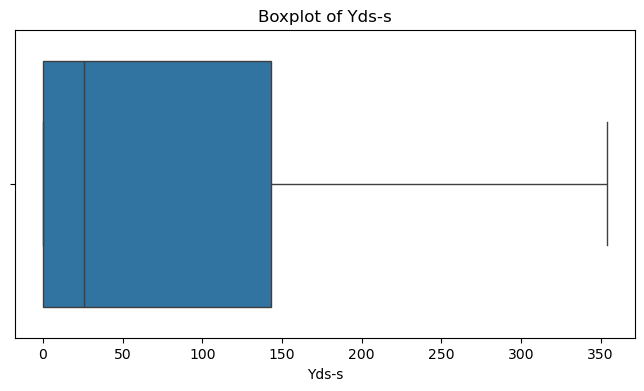

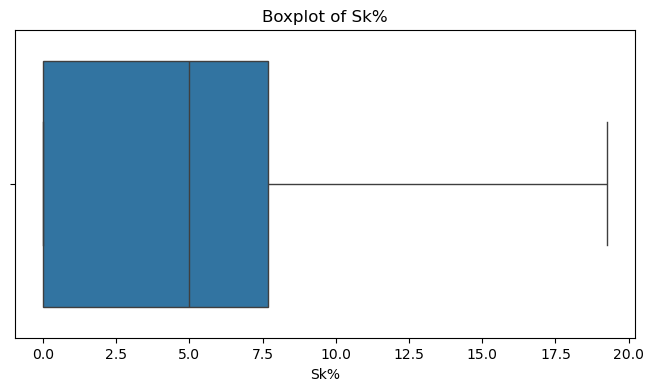

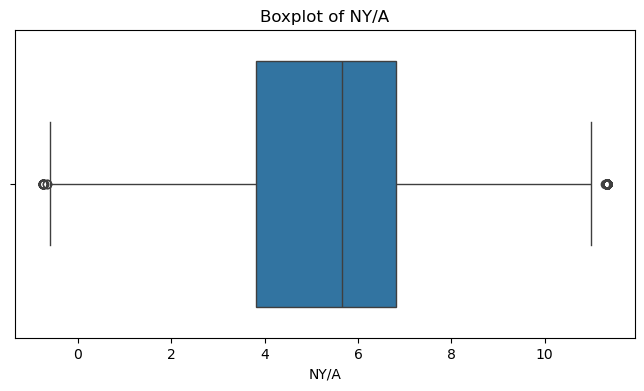

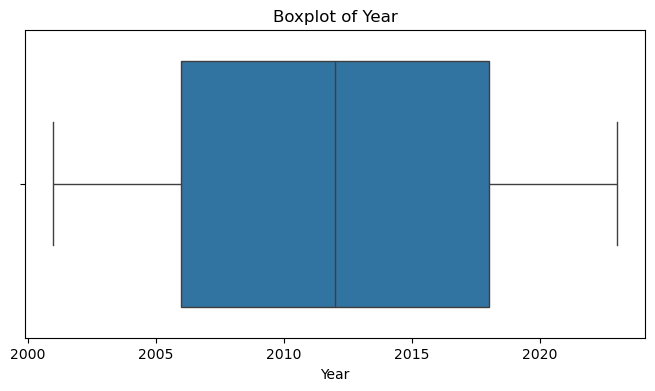

In [225]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show() 

In [227]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[numeric_cols]))

outliers = (z_scores > 3).sum()
print("Number of outliers per column:\n", outliers)

Number of outliers per column:
 Age       0
G         0
GS        0
Cmp       0
Att       0
Yds       0
TD        0
TD%       0
Int       0
Int%      0
1D        0
Lng       0
Y/C       0
Y/G       0
Rate      0
Sk       12
Yds-s     0
Sk%       0
NY/A      0
Year      0
dtype: int64


## Outlier Visualization

## In this portion, we analyzed boxplots and z-scores, showing that most variables do not contain significant outliers. A small number of outliers appear in the Sk (sacks) variable. These values are likely due to differences in player performance rather than data errors, so they were retained. Also, this is a defensive statistic, which is not necessary to calculate Quarterback performance. 

In [244]:
df = df.drop(columns=['Sk', 'Sk%', 'Yds-s'], errors='ignore')

## The Sk, Sk%, and Yds-s variables were removed as they relate to sacks, which are influenced by defensive pressure and offensive line performance. These variables are not essential for evaluating quarterback passing performance.

# Feature Relationships with Target Variable

## Relationships between features and the target variable were explored to understand which variables are associated with Pro Bowl selection-- or have relevance, if any at all. Thus far, the analysis indicates that higher values in passing performance metrics such as yards, touchdowns, and efficiency measures tend to correspond with a greater likelihood of selection. Indeed, we concluded that this is a good analysis, but it can improve significantly once we apply statistical predictive models. 

In [27]:
df.to_csv('Reginald_Tochukwu_cleaned_NFL_dataset.csv', index=False)